In [ ]:
!pip install  tensorflow-federated

## Normal Training

## Loan Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,roc_curve,confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from tensorflow_federated import learning
from collections import defaultdict


data = pd.read_csv('/content/loan-10k.lrn.csv')
final_X_test = pd.read_csv('/content/loan-10k.tes.csv')
final_Y_test = pd.read_csv('/content/loan-10k.sol.ex.csv')

y_train =  pd.DataFrame( data['grade'])
X_train =  pd.DataFrame( data.drop(['grade' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

### Neural Networks

In [8]:
le = LabelEncoder()
encoder = OneHotEncoder(handle_unknown='ignore')
#  for the features below we can use Label encoder, they seem ordinal
columns_to_transform = [
    'term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state'
]

for column in columns_to_transform:
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])


y_train["grade"] = le.fit_transform(y_train["grade"])
y_test["grade"] = le.fit_transform(y_test["grade"])
y_train = y_train.to_numpy().flatten()
y_test = y_test.to_numpy().flatten()
# We can drop the columns 'pymnt_plan' and 'addr_state' beacuse they do not have any useful information
X_train = X_train.drop('pymnt_plan', axis=1)
X_train = X_train.drop('hardship_flag', axis=1)

X_test = X_test.drop('pymnt_plan', axis=1)
X_test = X_test.drop('hardship_flag', axis=1)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

encoded = encoder.fit_transform(X_train[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_train = pd.concat([X_train, encoded_df], axis=1)
X_train = X_train.drop('home_ownership', axis=1)


encoded = encoder.transform(X_test[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_test = pd.concat([X_test, encoded_df], axis=1)
X_test = X_test.drop('home_ownership', axis=1)

Features = X_train.columns
Features_not_scaled = ['term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state' ,"home_ownership_ANY" ,
    "home_ownership_MORTGAGE" ,	"home_ownership_OTHER" ,	"home_ownership_OWN" ,  	"home_ownership_RENT" ]

Features_scaled = [x for x in Features if x not in Features_not_scaled]
scaler = StandardScaler()
X_train[Features_scaled] = scaler.fit_transform(X_train[Features_scaled])
X_test[Features_scaled] = scaler.transform(X_test[Features_scaled])


In [9]:

# 2. Simulate federated data distribution
def create_federated_data(x, y, num_clients=100):
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    for i, label in enumerate(y):
        class_indices[label].append(i)

    client_data = []
    classes_per_client = max(1, num_classes // num_clients)
    all_classes = np.arange(num_classes)

    for _ in range(num_clients):
        selected_classes = np.random.choice(all_classes, classes_per_client, replace=False)
        client_indices = []

        for cls in selected_classes:
            cls_idxs = class_indices[cls]
            cls_sampled = np.random.choice(cls_idxs, min(len(cls_idxs), len(x)//(num_clients*classes_per_client)), replace=False)
            client_indices.extend(cls_sampled)

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values.astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        ds = tf.data.Dataset.from_tensor_slices((client_x, client_y)).shuffle(100).batch(16).repeat(5)
        client_data.append(ds)

    return client_data


In [12]:
def federated_Learning( X_train , y_train,X_test, y_test, number_of_clients):
  federated_train_data = create_federated_data(X_train, y_train ,number_of_clients)
  def create_keras_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(7, activation='softmax')
    ])
  def model_fn():
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model(
    keras_model,
    input_spec=federated_train_data[0].element_spec,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

  trainer = learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,
    client_optimizer_fn=learning.optimizers.build_adam(learning_rate=0.01),
    server_optimizer_fn=learning.optimizers.build_sgdm(learning_rate=0.1)
  )
  state = trainer.initialize()
  print(f"Starting federated training... for {number_of_clients} clients ")
  max_accuracy = 0
  counter = 0
  while True:
      state, metrics = trainer.next(state, federated_train_data)
      final_model = trainer.get_model_weights(state).trainable
      keras_model = create_keras_model()
      keras_model.set_weights(final_model)
      keras_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
      loss, acc_test = keras_model.evaluate(X_test, y_test)
      if acc_test > max_accuracy:
        max_accuracy = acc_test
        counter = 0
      else:
        counter += 1
      if counter == 20:
        break


  return max_accuracy

In [13]:
max_acc = []
nodes = []
i =1
while i <= 100:

  max_accuracy = federated_Learning( X_train , y_train,X_test, y_test,i)
  max_acc.append(max_accuracy)
  nodes.append(i)
  if i <=11 :
    i +=1
  else :
    i += 10

Starting federated training... for 1 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.2907 - accuracy: 0.8890
Starting federated training... for 2 clients 
32/32 [==============================] - 0s 2ms/step - loss: 20.2505 - accuracy: 0.5680
Starting federated training... for 3 clients 
32/32 [==============================] - 0s 2ms/step - loss: 3.3338 - accuracy: 0.1790
Starting federated training... for 4 clients 
32/32 [==============================] - 0s 3ms/step - loss: 39.1963 - accuracy: 0.2990
Starting federated training... for 5 clients 
32/32 [==============================] - 0s 3ms/step - loss: 13.3413 - accuracy: 0.2990
Starting federated training... for 6 clients 
32/32 [==============================] - 1s 3ms/step - loss: 15.9457 - accuracy: 0.2890
Starting federated training... for 7 clients 
32/32 [==============================] - 0s 2ms/step - loss: 10.2763 - accuracy: 0.1880
Starting federated training... for 8 clients 
32/32 [===========

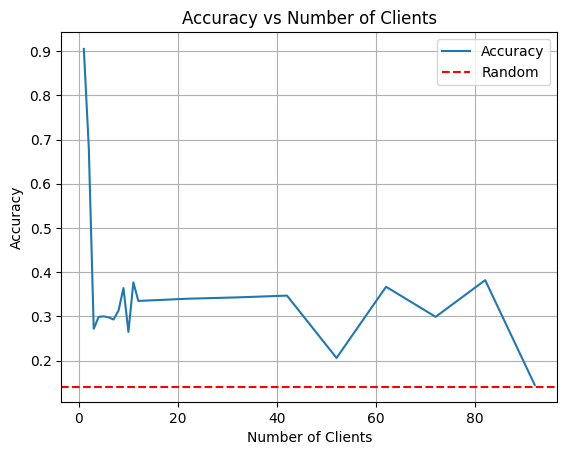

In [21]:
plot1(nodes , max_acc)

### Centralize

In [22]:
max_acc[0]

0.9049999713897705

## Appendix

In [20]:
import matplotlib.pyplot as plt
import numpy as np
def plot1(x, y):
    plt.plot(x, y, label='Accuracy')
    plt.axhline(y=0.14, color='red', linestyle='--', label='Random')
    plt.xlabel('Number of Clients')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Number of Clients')
    plt.legend()
    plt.grid(True)
    plt.show()